# Exploratory Data Analysis: CMS Hospital Performance

This notebook explores CMS hospital quality and utilization data prepared in the Gold layer of the lakehouse pipeline. The analysis investigates patterns in hospital performance, readmission behavior, patient volume, and spending metrics. The goal is to identify meaningful relationships in the data and prepare features for downstream machine learning models that predict hospital readmission risk.


### Objective:
* Explore the Gold ML feature table and perform exploratory data analysis to identify patterns in hospital performance, readmission behavior, patient utilization, and cost metrics. The analysis generates project-ready insights and visualizations that support downstream machine learning modeling.

# 1 Dataset Overview

In [0]:
from pyspark.sql import functions as F

GOLD = "/Volumes/workspace/cms_hospital/gold"

def read_delta(path):
    return spark.read.format("delta").load(path)

gold_ml = read_delta(f"{GOLD}/ml_features")
gold_hosp = read_delta(f"{GOLD}/hospital_features")

print("gold_ml rows:", gold_ml.count())
print("gold_hosp rows:", gold_hosp.count)

gold_ml rows: 18330
gold_hosp rows: <bound method DataFrame.count of DataFrame[facility_id: string, facility_name: string, state: string, start_date: date, end_date: date, zip_code: string, measure_name: string, number_of_discharges: int, number_of_readmissions: int, predicted_readmission_rate: double, expected_readmission_rate: double, excess_readmission_ratio: double, hospital_type: string, hospital_ownership: string, emergency_services: string, hospital_overall_rating: int, birthing_friendly_designation: string, ruca_code: double, secondary_ruca_code: double, ruca_bucket: string, mspb_score: double, avg_unplanned_score: double, total_unplanned_denominator: bigint, total_unplanned_patients: bigint, total_unplanned_patients_returned: bigint, unplanned_return_rate: double, is_emergency_services: int, has_hospital_rating: int, high_quality_hospital: int, high_patient_volume: int, is_rural: int, readmission_gap: double, observed_readmission_rate: double, high_readmission_flag: int]>


In [0]:
# Schema view for gold_ml
gold_ml.printSchema()
display(gold_ml.limit(20))

root
 |-- facility_id: string (nullable = true)
 |-- facility_name: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- measure_name: string (nullable = true)
 |-- start_date: date (nullable = true)
 |-- end_date: date (nullable = true)
 |-- hospital_type: string (nullable = true)
 |-- hospital_ownership: string (nullable = true)
 |-- hospital_overall_rating: integer (nullable = true)
 |-- birthing_friendly_designation: string (nullable = true)
 |-- is_emergency_services: integer (nullable = true)
 |-- has_hospital_rating: integer (nullable = true)
 |-- high_quality_hospital: integer (nullable = true)
 |-- high_patient_volume: integer (nullable = true)
 |-- is_rural: integer (nullable = true)
 |-- mspb_score: double (nullable = true)
 |-- avg_unplanned_score: double (nullable = true)
 |-- total_unplanned_denominator: long (nullable = true)
 |-- total_unplanned_patients: long (nullable = true)
 |-- total_unplanned_patients_returned:

facility_id,facility_name,state,zip_code,measure_name,start_date,end_date,hospital_type,hospital_ownership,hospital_overall_rating,birthing_friendly_designation,is_emergency_services,has_hospital_rating,high_quality_hospital,high_patient_volume,is_rural,mspb_score,avg_unplanned_score,total_unplanned_denominator,total_unplanned_patients,total_unplanned_patients_returned,unplanned_return_rate,ruca_code,secondary_ruca_code,ruca_bucket,predicted_readmission_rate,expected_readmission_rate,readmission_gap,observed_readmission_rate,excess_readmission_ratio,high_readmission_flag
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-AMI-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,null,null,null,null,null,0
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-CABG-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,null,null,null,null,null,0
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-COPD-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,16.5931,16.2168,0.3763000000000005,null,1.0232,1
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-HF-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,19.6947,18.5446,1.150100000000002,0.3076923076923077,1.062,1
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-HIP-KNEE-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,null,null,null,null,null,0
010007,MIZELL MEMORIAL HOSPITAL,AL,36467,READM-30-PN-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Voluntary non-profit - Private,1,null,1,1,0,0,1,1.04,27.371428571428574,575,116,49,0.4224137931034483,7.0,7.0,rural_small_town,16.336,15.7913,0.5446999999999989,0.19047619047619047,1.0345,1
010008,CRENSHAW COMMUNITY HOSPITAL,AL,36049,READM-30-AMI-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Proprietary,null,null,1,0,0,0,1,1.14,8.625,206,28,8,0.2857142857142857,10.0,10.0,rural_small_town,null,null,null,null,null,0
010008,CRENSHAW COMMUNITY HOSPITAL,AL,36049,READM-30-CABG-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Proprietary,null,null,1,0,0,0,1,1.14,8.625,206,28,8,0.2857142857142857,10.0,10.0,rural_small_town,null,null,null,null,null,0
010008,CRENSHAW COMMUNITY HOSPITAL,AL,36049,READM-30-COPD-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Proprietary,null,null,1,0,0,0,1,1.14,8.625,206,28,8,0.2857142857142857,10.0,10.0,rural_small_town,null,null,null,null,null,0
010008,CRENSHAW COMMUNITY HOSPITAL,AL,36049,READM-30-HF-HRRP,2021-07-01,2024-06-30,Acute Care Hospitals,Proprietary,null,null,1,0,0,0,1,1.14,8.625,206,28,8,0.2857142857142857,10.0,10.0,rural_small_town,null,null,null,null,null,0


In [0]:
# Sanity check on the number of unique facility ids
print("gold_ml count:", gold_ml.count())
print("gold_ml unique facility ids: ",gold_ml.select("facility_id").distinct().count())

gold_ml count: 18330
gold_ml unique facility ids:  3055


# 2 Missingness Analysis

In [0]:
# missing values for each column in gold_ml
missing_df = gold_ml.select(
  [
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in gold_ml.columns
  ]
)

display(missing_df)

facility_id,facility_name,state,zip_code,measure_name,start_date,end_date,hospital_type,hospital_ownership,hospital_overall_rating,birthing_friendly_designation,is_emergency_services,has_hospital_rating,high_quality_hospital,high_patient_volume,is_rural,mspb_score,avg_unplanned_score,total_unplanned_denominator,total_unplanned_patients,total_unplanned_patients_returned,unplanned_return_rate,ruca_code,secondary_ruca_code,ruca_bucket,predicted_readmission_rate,expected_readmission_rate,readmission_gap,observed_readmission_rate,excess_readmission_ratio,high_readmission_flag
0,0,0,0,0,0,0,0,0,3150,6072,0,0,0,0,0,1014,516,516,1914,1914,1914,0,0,0,6610,6610,6610,10293,6610,0


## 2.1 Transpose Missing Values Table
* Column-wise summary of null counts and percentages

In [0]:
missing_long = []

row = missing_df.collect()[0].asDict()
total_rows = gold_ml.count()

for col_name, null_count in row.items():
  missing_long.append((col_name, null_count, round(null_count/ total_rows, 4)))


missing_long_df = spark.createDataFrame(
  missing_long,
  ["col_name", "null_count", "null_pct"]
).orderBy(F.desc("null_count"))

display(missing_long_df)
                                        

col_name,null_count,null_pct
observed_readmission_rate,10293,0.5615
predicted_readmission_rate,6610,0.3606
expected_readmission_rate,6610,0.3606
readmission_gap,6610,0.3606
excess_readmission_ratio,6610,0.3606
birthing_friendly_designation,6072,0.3313
hospital_overall_rating,3150,0.1718
total_unplanned_patients,1914,0.1044
total_unplanned_patients_returned,1914,0.1044
unplanned_return_rate,1914,0.1044


Target variable distribution

In [0]:
# examine the distribution of the excess readmission ratio
display(gold_ml.select("excess_readmission_ratio").limit(10))

# examine the distribution of the predicted readmission rate
display(
    gold_ml.groupBy("high_readmission_flag")
    .agg(F.count("*").alias("count"))
    .orderBy("high_readmission_flag")
    )

excess_readmission_ratio
null
null
1.0232
1.062
null
1.0345
null
null
null
null


high_readmission_flag,count
0,12687
1,5643


# 3 Summary Analysis
Summary statistics for key numeric features (Hospital info)

In [0]:
# 1. Identify numeric columns using list comprehension of hospital_features
numeric_cols = [(c, t) for c, t in gold_hosp.dtypes if t in ('int', 'double', 'bigint', 'float')]

# 2. Print each numeric column's name and type
for c, t in numeric_cols:
    print(f"Column: {c}, Type: {t}")

Column: number_of_discharges, Type: int
Column: number_of_readmissions, Type: int
Column: predicted_readmission_rate, Type: double
Column: expected_readmission_rate, Type: double
Column: excess_readmission_ratio, Type: double
Column: hospital_overall_rating, Type: int
Column: ruca_code, Type: double
Column: secondary_ruca_code, Type: double
Column: mspb_score, Type: double
Column: avg_unplanned_score, Type: double
Column: total_unplanned_denominator, Type: bigint
Column: total_unplanned_patients, Type: bigint
Column: total_unplanned_patients_returned, Type: bigint
Column: unplanned_return_rate, Type: double
Column: is_emergency_services, Type: int
Column: has_hospital_rating, Type: int
Column: high_quality_hospital, Type: int
Column: high_patient_volume, Type: int
Column: is_rural, Type: int
Column: readmission_gap, Type: double
Column: observed_readmission_rate, Type: double
Column: high_readmission_flag, Type: int


In [0]:
# Assign the list of numeric columns to a variable with continuous values of hospital_features
numeric_cols = [
    "number_of_discharges",
    "number_of_readmissions",
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "excess_readmission_ratio",
    "mspb_score",
    "avg_unplanned_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "readmission_gap",
    "observed_readmission_rate",
    "hospital_overall_rating",
    "ruca_code"
]

# Print the summary statistics of the selected numeric columns
display(gold_hosp.select(numeric_cols).summary())

summary,number_of_discharges,number_of_readmissions,predicted_readmission_rate,expected_readmission_rate,excess_readmission_ratio,mspb_score,avg_unplanned_score,total_unplanned_patients,unplanned_return_rate,readmission_gap,observed_readmission_rate,hospital_overall_rating,ruca_code
count,8242,8037,11720,11720,11720,17316,17814,16416,16416,11720,8037,15180,18330
mean,283.4162824557146,48.750653228816724,14.981461023890756,14.947978412969258,1.0017768259385635,0.9907830907830905,11.395159149633889,639.6641081871345,0.2926675514782076,0.03348261092150168,0.17111566877251,3.032806324110672,2.2916530278232408
stddev,270.9290233691943,49.75820618512481,4.76365485030903,4.62086459905157,0.08205013380990803,0.08776329349554499,6.679896256499719,617.4732615649383,0.04406284284166335,1.023375133192685,0.05069278096729524,1.084288262566382,2.341125292826072
min,0,11,1.908,3.0876,0.4698,0.54,-11.159999999999998,19,0.08,-5.295,0.013959390862944163,1,1.0
25%,117,19,12.5258,12.6222,0.9582,0.94,7.5307692307692315,195,0.26846057571964954,-0.5874000000000006,0.13959390862944163,2,1.0
50%,198,31,15.8596,15.8552,0.9972,0.99,10.600000000000001,460,0.2908496732026144,-0.0387000000000004,0.17045454545454544,3,1.0
75%,358,60,18.4154,18.4999,1.0423,1.04,14.358333333333336,891,0.3157894736842105,0.6049000000000007,0.20126671358198453,4,4.0
max,3672,847,28.1643,26.8654,1.6297,1.43,76.33333333333333,6725,0.6323529411764706,7.304299999999998,0.5,5,10.0


In [0]:
# Show the summary statistics for the selected columns
display(
    gold_ml.select("excess_readmission_ratio").describe()
)

summary,excess_readmission_ratio
count,11720
mean,1.0017768259385635
stddev,0.08205013380990803
min,0.4698
max,1.6297


# 4 Hospital Readmission Analysis

## 4.1 State Level Readmission Analysis

### 4.1.1 State Readmission Summary Table

In [0]:
# State level readmission summary
state_summary = (
    gold_ml.groupBy("state")
    .agg(
        F.count("*").alias("row_count"),
        F.avg("excess_readmission_ratio").alias("avg_excess_readmission_ratio"),
        F.avg("predicted_readmission_rate").alias("avg_predicted_readmission_rate"),
        F.avg("expected_readmission_rate").alias("avg_expected_readmission_rate"),
        F.avg("mspb_score").alias("avg_mspb_score"),
        F.avg("total_unplanned_patients").alias("avg_total_unplanned_patients"),
        F.avg("high_readmission_flag").alias("pct_high_readmission")
    )
    .orderBy(F.desc("avg_excess_readmission_ratio"))
)

display(state_summary)

state,row_count,avg_excess_readmission_ratio,avg_predicted_readmission_rate,avg_expected_readmission_rate,avg_mspb_score,avg_total_unplanned_patients,pct_high_readmission
MA,330,1.0344279166666668,14.908685833333339,14.383137500000002,0.978269230769234,1221.734693877551,0.45454545454545453
NJ,366,1.027668014705882,16.036789338235288,15.615086764705886,1.076065573770491,979.8524590163935,0.48633879781420764
FL,1014,1.0228664072632954,15.78354098573281,15.467181841763924,1.0204268292682919,889.0731707317074,0.4368836291913215
IL,684,1.0193904276985737,15.784370468431776,15.529865580448064,0.9995535714285708,760.9174311926605,0.4152046783625731
MS,354,1.0140940540540548,15.185147027027025,14.94543675675676,0.9940384615384628,451.58,0.3192090395480226
AL,462,1.0138842105263162,14.662346558704451,14.50963522267207,0.985428571428569,411.875,0.2813852813852814
WV,150,1.011502105263158,15.95206631578947,15.69564421052631,1.0013043478260866,635.3809523809524,0.34
NV,132,1.0114382978723409,14.803573404255317,14.587387234042554,1.0540000000000007,746.6842105263158,0.36363636363636365
GA,564,1.011402601156069,15.464458092485547,15.30856098265897,0.9648351648351641,551.5454545454545,0.3421985815602837
KY,354,1.0101352422907484,16.412251982378862,16.271085022026426,1.007118644067795,520.4067796610169,0.3474576271186441


In [0]:
#Top 10 states with highest avg excess readmission ratio
#This is the deviation from expected performance
display(
    gold_ml.groupBy("state")
    .agg(F.avg("excess_readmission_ratio").alias("avg_excess_ratio"))
    .orderBy(F.desc("avg_excess_ratio"))
    .limit(10)
)

state,avg_excess_ratio
MA,1.0344279166666668
NJ,1.027668014705882
FL,1.0228664072632954
IL,1.0193904276985737
MS,1.0140940540540548
AL,1.0138842105263162
WV,1.011502105263158
NV,1.0114382978723409
GA,1.011402601156069
KY,1.0101352422907484


### 4.1.2 Choropleth Map: Readmission Ratio by State
To better understand geographic variation in hospital performance, a choropleth map was created using the average excess readmission ratio by state. This visualization highlights regional differences in hospital readmission burden across the United States.

In [0]:
# view the columns for the gold_ml spark DataFrame
gold_ml.columns

['facility_id',
 'facility_name',
 'state',
 'zip_code',
 'measure_name',
 'start_date',
 'end_date',
 'hospital_type',
 'hospital_ownership',
 'hospital_overall_rating',
 'birthing_friendly_designation',
 'is_emergency_services',
 'has_hospital_rating',
 'high_quality_hospital',
 'high_patient_volume',
 'is_rural',
 'mspb_score',
 'avg_unplanned_score',
 'total_unplanned_denominator',
 'total_unplanned_patients',
 'total_unplanned_patients_returned',
 'unplanned_return_rate',
 'ruca_code',
 'secondary_ruca_code',
 'ruca_bucket',
 'predicted_readmission_rate',
 'expected_readmission_rate',
 'readmission_gap',
 'observed_readmission_rate',
 'excess_readmission_ratio',
 'high_readmission_flag']

In [0]:
gold_ml.describe

<bound method DataFrame.describe of DataFrame[facility_id: string, facility_name: string, state: string, zip_code: string, measure_name: string, start_date: date, end_date: date, hospital_type: string, hospital_ownership: string, hospital_overall_rating: int, birthing_friendly_designation: string, is_emergency_services: int, has_hospital_rating: int, high_quality_hospital: int, high_patient_volume: int, is_rural: int, mspb_score: double, avg_unplanned_score: double, total_unplanned_denominator: bigint, total_unplanned_patients: bigint, total_unplanned_patients_returned: bigint, unplanned_return_rate: double, ruca_code: double, secondary_ruca_code: double, ruca_bucket: string, predicted_readmission_rate: double, expected_readmission_rate: double, readmission_gap: double, observed_readmission_rate: double, excess_readmission_ratio: double, high_readmission_flag: int]>

In [0]:
import pyspark.sql.functions as F
# Create a DataFrame with state and average excess readmission ratio
state_df = (
    gold_ml
    .groupBy("state")
    .agg(
        F.avg("excess_readmission_ratio").alias("avg_excess_readmission_ratio"),
        F.count("*").alias("hospital_count")
    )
)

display(state_df)

state,avg_excess_readmission_ratio,hospital_count
IL,1.0193904276985737,684
NJ,1.027668014705882,366
CA,1.0100765895953756,1662
IN,0.9976389408099695,492
OK,0.9979871681415932,456
WY,0.9853696969696968,48
CT,0.9967455357142857,162
WV,1.011502105263158,150
MN,0.9778257142857141,276
ND,0.9466485714285712,42


In [0]:
# Convert the state_df to a pandas DataFrame
state_pd = state_df.toPandas()

# Create Choropleth map using plotly express
import plotly.express as px

fig = px.choropleth(
    state_pd,
    locations="state",
    locationmode="USA-states",
    color="avg_excess_readmission_ratio",
    scope="usa",
    color_continuous_scale="Viridis",
    hover_name="state",
    hover_data=["avg_excess_readmission_ratio"],
    labels={"avg_excess_readmission_ratio":"Avg Excess Readmission Ratio"},
    title="Average Excess Readmission Ratio by State"
)

# Add state labels to the map using scattergeo
fig.add_scattergeo(
    locations=state_pd["state"],
    locationmode="USA-states",
    text=state_pd["state"],
    mode="text",
    hoverinfo='skip',
    showlegend=False
)

fig.show()

**4.1.2 Choropleth Map Output:** The state-level maps show that hospital readmission performance varies across the United States. Some states have average excess readmission ratios above 1.0, indicating higher readmission burden relative to expectations, while others fall below 1.0. 

**Note:** The bubble map also shows that states differ substantially in hospital count, which is important when interpreting the stability of state averages.

### 4.1.3 Bubble Map: Hospital Readmission Ratio with Hospital Count by State
A complementary bubble map was also created to add context to the state-level readmission analysis. In this view, color represents the average excess readmission ratio and bubble size represents the number of hospitals contributing to each state’s average. This helps distinguish between states with broader hospital representation and states with relatively fewer observations.

In [0]:
# Create bubble map using plotly express for hospital count and excess readmission ratio by state
import plotly.express as px

fig = px.scatter_geo(
    state_pd,
    locations="state",
    locationmode="USA-states",
    size="hospital_count",
    color="avg_excess_readmission_ratio",
    scope="usa",
    color_continuous_scale="Viridis",
    size_max=28,   # slightly larger bubbles
    hover_name="state",
    hover_data={
        "hospital_count": True,
        "avg_excess_readmission_ratio": ":.3f"
    },
    title="Hospital Readmission Ratio with Hospital Count by State"
)

# Map appearance improvements
fig.update_geos(
    showcountries=False,
    showcoastlines=False,
    showland=True,
    landcolor="rgb(235, 235, 235)",
    lakecolor="white"
)

# Layout improvements
fig.update_layout(
    title_x=0.5,  # center title
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

**4.1.3 Bubble Map Output:** The bubble map adds additional context to the state-level readmission analysis by incorporating hospital count into the visualization. While color represents the **average excess readmission ratio**, the bubble size indicates **how many hospitals** contributed to the state-level average.

States with larger bubbles represent regions with a higher number of hospitals in the dataset, meaning the calculated averages are based on a broader sample of facilities. Conversely, smaller bubbles indicate states with fewer hospitals, where the average readmission ratio may be influenced by a smaller number of observations.

This visualization helps interpret the reliability of the state-level averages and highlights states with both high readmission ratios and large hospital representation.

## 4.2 Hospital Type Readmission Analysis

In [0]:
# Hospital type excess readmission ratio and pct high readmission summary
display(
    gold_ml.groupBy("hospital_type")
    .agg(
        F.count("*").alias("count"),
        F.avg("excess_readmission_ratio").alias("avg_err"),
        F.avg("high_readmission_flag").alias("pct_high_readmission")
    )
    .orderBy(F.desc("count"))
)

hospital_type,count,avg_err,pct_high_readmission
Acute Care Hospitals,18330,1.0017768259385635,0.3078559738134206


## 4.3 Hospital Ownership Readmission Analysis

In [0]:
# hospital ownership excess readmission ratio and pct high readmission summary
display(
    gold_ml.groupBy("hospital_ownership")
    .agg(
        F.count("*").alias("count"),
        F.avg("excess_readmission_ratio").alias("avg_err"),
        F.avg("high_readmission_flag").alias("pct_high_readmission")
    )
    .orderBy(F.desc("count"))
)

hospital_ownership,count,avg_err,pct_high_readmission
Voluntary non-profit - Private,8778,0.998818801888328,0.3247892458418774
Proprietary,3750,1.0173506407214041,0.3082666666666667
Voluntary non-profit - Other,1512,0.9999827098078864,0.30753968253968256
Government - Hospital District or Authority,1362,0.9996436061381069,0.2709251101321586
Voluntary non-profit - Church,1230,0.9939993478260859,0.32682926829268294
Government - Local,822,1.0027756871035949,0.305352798053528
Physician,420,0.9493285714285713,0.08333333333333333
Government - State,264,1.0000426829268296,0.3181818181818182
Government - Federal,150,1.0173363636363637,0.18666666666666668
Tribal,42,0.9810714285714285,0.047619047619047616


# 5 Rural vs Metro Comparison

In [0]:
# rural summary for rural hospitals
rural_summary = (
    gold_ml.groupBy("ruca_bucket")
    .agg(
        F.count("*").alias("row_count"),
        F.avg("excess_readmission_ratio").alias("avg_excess_readmission_ratio"),
        F.avg("high_readmission_flag").alias("pct_high_readmission"),
        F.avg("mspb_score").alias("avg_mspb_score"),
        F.avg("total_unplanned_patients").alias("avg_total_unplanned_patients")
    )
    .orderBy(F.desc("avg_excess_readmission_ratio"))
)

rural_summary.display()

ruca_bucket,row_count,avg_excess_readmission_ratio,pct_high_readmission,avg_mspb_score,avg_total_unplanned_patients
metro,13236,1.00316,0.3362042913266848,1.0006216867469808,787.1480908152735
micro,3414,0.9978914925373139,0.2665495020503808,0.9680720720720709,340.54430379746833
rural_small_town,1680,0.9943078740157467,0.16845238095238096,0.9602734375000005,148.19183673469388


# 6 Feature Distributions & Skewness

## 6.1 Univariate Analysis
* Histograms showing the distribution of key target/predictor variables;
  * Excess Readmission Ratio
  * MSPB Score Distribution
  * Total Unplanned Patients

### 6.1.1 Excess Readmission Ratio - Histogram

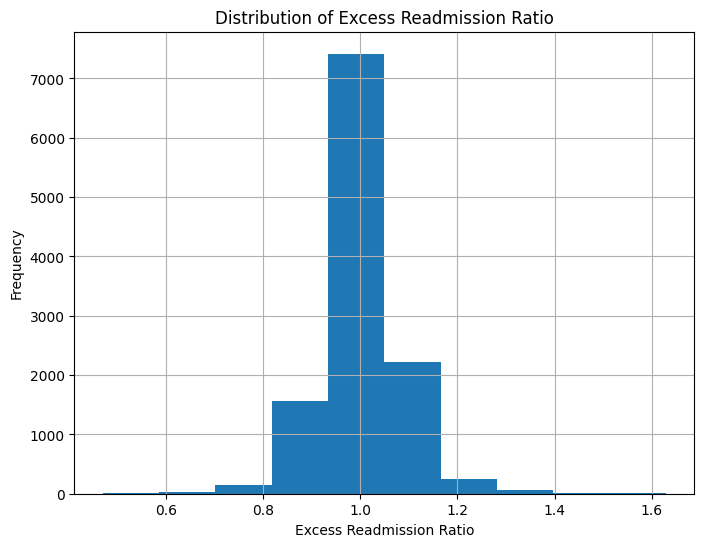

In [0]:
import matplotlib.pyplot as plt

gold_ml.select("excess_readmission_ratio").toPandas().hist(figsize=(8, 6))
plt.title("Distribution of Excess Readmission Ratio")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Frequency")
plt.show()

### 6.1.2 MSPB Score - Histogram

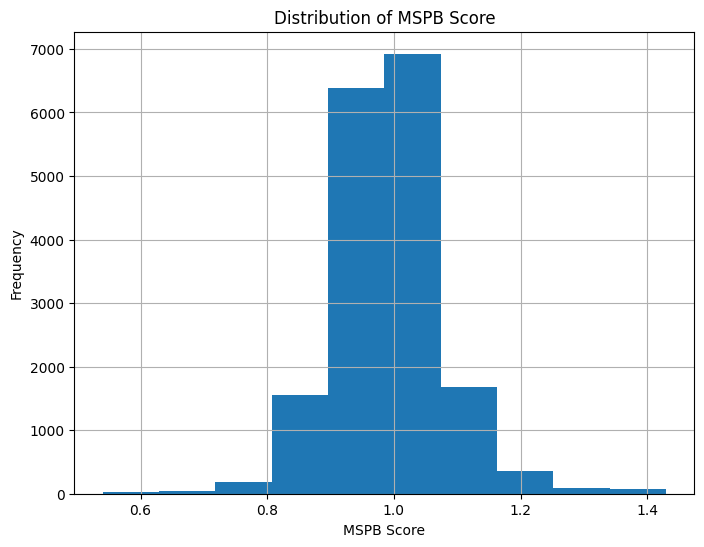

In [0]:
gold_ml.select("mspb_score").dropna().toPandas().hist(figsize=(8, 6))
plt.title("Distribution of MSPB Score")
plt.xlabel("MSPB Score")
plt.ylabel("Frequency")
plt.show()

### 6.1.3 Total Unplanned Patients - Histogram

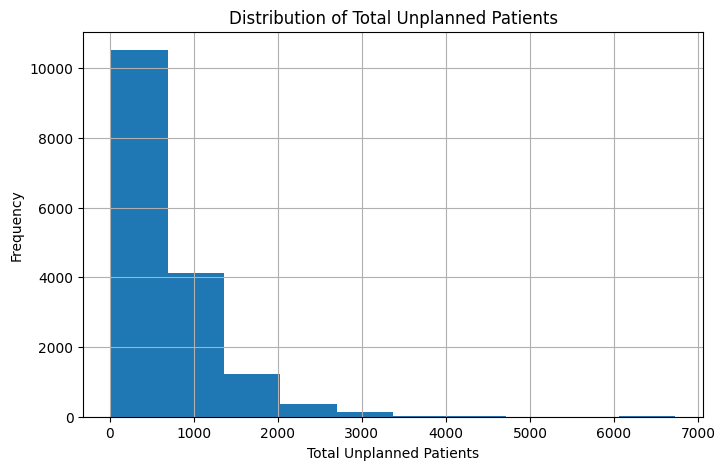

In [0]:
gold_ml.select("total_unplanned_patients").dropna().toPandas().hist(figsize=(8, 5))
plt.title("Distribution of Total Unplanned Patients")
plt.xlabel("Total Unplanned Patients")
plt.ylabel("Frequency")
plt.show()

## 6.2 Hospital Rating Performance by Rurality
* Average excess readmission ratio grouped by star rating and rural/urban classification. Reveals if low-rated rural hospitals underperform.

In [0]:
# 
rating_summary = (
    gold_ml.groupBy("hospital_overall_rating", "ruca_bucket")
    .agg(
        F.count("*").alias("rows"),
        F.avg("excess_readmission_ratio").alias("avg_excess_readmit_ratio")
    )
    .orderBy("hospital_overall_rating", "ruca_bucket")
)

display(rating_summary)

hospital_overall_rating,ruca_bucket,rows,avg_excess_readmit_ratio
null,metro,1782,0.9783
null,micro,528,0.9846408163265306
null,rural_small_town,840,0.9957758241758242
1,metro,990,1.0431348804500695
1,micro,222,1.0337410958904105
1,rural_small_town,42,1.0393391304347823
2,metro,2610,1.0221662122687434
2,micro,780,1.012358571428571
2,rural_small_town,234,1.0077024193548392
3,metro,3654,1.0090119272472862


Databricks visualization. Run in Databricks to view.

## 6.3 Skewness Assessment

In [0]:
# Skewness for gold_ml numeric features
from pyspark.sql.functions import skewness

gold_ml_skewness = gold_ml.select(
    skewness("predicted_readmission_rate").alias("predicted_readmission_rate"),
    skewness("expected_readmission_rate").alias("expected_readmission_rate"),
    skewness("excess_readmission_ratio").alias("excess_readmission_ratio"),
    skewness("hospital_overall_rating").alias("hospital_overall_rating"),
    skewness("mspb_score").alias("mspb_score"),
    skewness("avg_unplanned_score").alias("avg_unplanned_score"),
    skewness("total_unplanned_patients").alias("total_unplanned_patients"),
    skewness("unplanned_return_rate").alias("unplanned_return_rate"),
    skewness("readmission_gap").alias("readmission_gap")
)

display(gold_ml_skewness)

predicted_readmission_rate,expected_readmission_rate,excess_readmission_ratio,hospital_overall_rating,mspb_score,avg_unplanned_score,total_unplanned_patients,unplanned_return_rate,readmission_gap
-0.6879001394032432,-0.8036668181411705,0.56173760873108,-0.05203767985148892,0.3590291510722471,1.9850721403606173,2.3731647730103056,0.3110239122031535,0.4117819603672634


# 7 Categorical & Segment Analysis

In [0]:
gold_hosp.select(F.col("ruca_code")).distinct().display()

ruca_code
6.0
1.0
10.0
5.0
7.0
4.0
8.0
9.0
3.0
2.0


## 7.1 Bivariate Visualization
* Comparative Analysis (Scatter Plot using Pandas & Matplotlib + Jitter)
    * Jitter helps to distinguish discrete values by adding a tiny random horizontal offset.

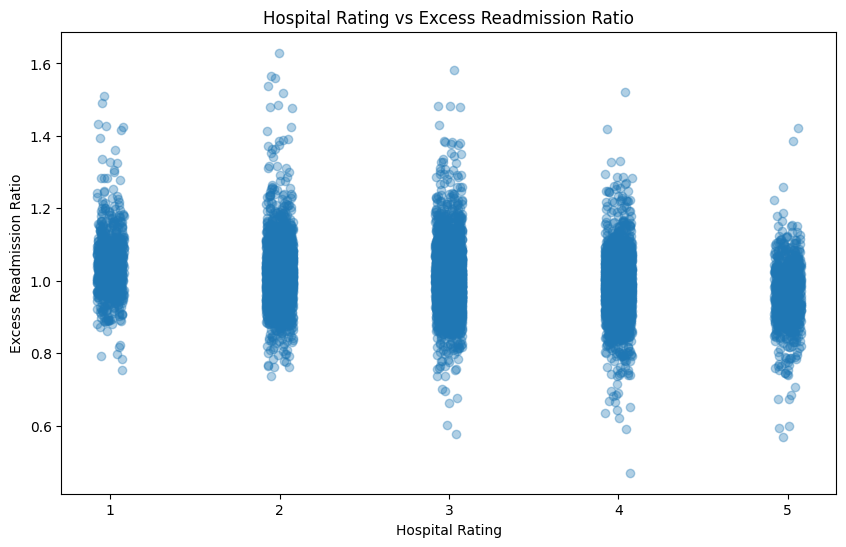

In [0]:
import numpy as np
import matplotlib.pyplot as plt

corr_plot_pd = gold_ml.select(F.col("excess_readmission_ratio"),
                              F.col("hospital_overall_rating")).toPandas()


plot_df = corr_plot_pd.copy()
plot_df["hospital_rating_jitter"] = plot_df["hospital_overall_rating"] + np.random.uniform(-0.08, 0.08, len(plot_df))

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["hospital_rating_jitter"],
    plot_df["excess_readmission_ratio"],
    alpha=0.35
)

plt.xlabel("Hospital Rating")
plt.ylabel("Excess Readmission Ratio")
plt.title("Hospital Rating vs Excess Readmission Ratio")
plt.show()

**7.1 Output:** Relationship Between Hospital Rating and Readmission Burden

Hospitals with higher CMS overall ratings tend to exhibit lower excess readmission ratios.
Average readmission ratios decline steadily from rating 1 hospitals to rating 5 hospitals, suggesting that hospitals with stronger overall performance also demonstrate better readmission outcomes.

# 8 Correlation Analysis

Note: Not every hospital report measures such as HF, PN, AMI, etc. That's why the outcome variables may be missing by design and this is not a data quality but domain missingniss. Correlation analysis therefore uses pairwise available observations
rather than dropping rows globally.

We remove following features from correlation analysis;
* Observed_readmission_rate -> 56% missing.
* Ruca_bucket -> This is a geographic classification code, not a continuous measure.

## 8.1 Pearson Correlation Matrix
* We use a custom PySpark SQL implementation to bypass environment-specific security restrictions.

In [0]:
# Check for null values in the selected columns
corr_cols = [
    "number_of_discharges",
    "number_of_readmissions",
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "excess_readmission_ratio",
    "hospital_overall_rating",
    "mspb_score",
    "avg_unplanned_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "ruca_code",
    "readmission_gap",
    "observed_readmission_rate"
]

# Check null counts for each selected column
corr_df = gold_hosp.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in corr_cols
])
display(corr_df)

number_of_discharges,number_of_readmissions,predicted_readmission_rate,expected_readmission_rate,excess_readmission_ratio,hospital_overall_rating,mspb_score,avg_unplanned_score,total_unplanned_patients,unplanned_return_rate,ruca_code,readmission_gap,observed_readmission_rate
10088,10293,6610,6610,6610,3150,1014,516,1914,1914,0,6610,10293


In [0]:
# Correlation between excess readmission ratio and mspb score
gold_hosp.stat.corr("excess_readmission_ratio", "mspb_score")

0.2126899084846601

In [0]:
# Select columns for correlation analysis
corr_cols = [
    "number_of_discharges",
    "number_of_readmissions",
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "excess_readmission_ratio",
    "hospital_overall_rating",
    "mspb_score",
    "avg_unplanned_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "readmission_gap"
]

target = "excess_readmission_ratio"

for c in corr_cols:
    if c != target:
        corr = gold_hosp.stat.corr(target, c)
        print(f"{target} vs {c}: {corr}")

excess_readmission_ratio vs number_of_discharges: 0.40990876074490795
excess_readmission_ratio vs number_of_readmissions: 0.403297592231228
excess_readmission_ratio vs predicted_readmission_rate: 0.8888163325164673
excess_readmission_ratio vs expected_readmission_rate: 0.8820908786321452
excess_readmission_ratio vs hospital_overall_rating: 0.32142882987071025
excess_readmission_ratio vs mspb_score: 0.2126899084846601
excess_readmission_ratio vs avg_unplanned_score: 0.06858808266505136
excess_readmission_ratio vs total_unplanned_patients: 0.42585405450488606
excess_readmission_ratio vs unplanned_return_rate: 0.376471320469245
excess_readmission_ratio vs readmission_gap: 0.1392023271085979


In [0]:
gold_hosp.columns

['facility_id',
 'facility_name',
 'state',
 'start_date',
 'end_date',
 'zip_code',
 'measure_name',
 'number_of_discharges',
 'number_of_readmissions',
 'predicted_readmission_rate',
 'expected_readmission_rate',
 'excess_readmission_ratio',
 'hospital_type',
 'hospital_ownership',
 'emergency_services',
 'hospital_overall_rating',
 'birthing_friendly_designation',
 'ruca_code',
 'secondary_ruca_code',
 'ruca_bucket',
 'mspb_score',
 'avg_unplanned_score',
 'total_unplanned_denominator',
 'total_unplanned_patients',
 'total_unplanned_patients_returned',
 'unplanned_return_rate',
 'is_emergency_services',
 'has_hospital_rating',
 'high_quality_hospital',
 'high_patient_volume',
 'is_rural',
 'readmission_gap',
 'observed_readmission_rate',
 'high_readmission_flag']

## 8.2 Correlation Heatmap
* Correlation analysis using pandas and seaborn - Heatmap 

In [0]:
# Select columns for correlation analysis
corr_cols = [
    "predicted_readmission_rate",
    "expected_readmission_rate",
    "excess_readmission_ratio",
    "hospital_overall_rating",
    "mspb_score",
    "avg_unplanned_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "readmission_gap"
]

# Convert the Spark DataFrame to a Pandas DataFrame
corr_pd = gold_ml.select(corr_cols).toPandas()
corr_pd.head()

,predicted_readmission_rate,expected_readmission_rate,excess_readmission_ratio,hospital_overall_rating,mspb_score,avg_unplanned_score,total_unplanned_patients,unplanned_return_rate,readmission_gap
0,NaN,NaN,NaN,1.0,1.04,27.371429,116.0,0.422414,NaN
1,NaN,NaN,NaN,1.0,1.04,27.371429,116.0,0.422414,NaN
2,16.5931,16.2168,1.0232,1.0,1.04,27.371429,116.0,0.422414,0.3763
3,19.6947,18.5446,1.0620,1.0,1.04,27.371429,116.0,0.422414,1.1501
4,NaN,NaN,NaN,1.0,1.04,27.371429,116.0,0.422414,NaN


In [0]:
# Calculate the correlation matrix
corr_matrix = corr_pd.corr()
corr_matrix

,predicted_readmission_rate,expected_readmission_rate,excess_readmission_ratio,hospital_overall_rating,mspb_score,avg_unplanned_score,total_unplanned_patients,unplanned_return_rate,readmission_gap
predicted_readmission_rate,1.000000,0.976674,0.208104,-0.113643,0.087506,0.195398,-0.107342,0.190899,0.244852
expected_readmission_rate,0.976674,1.000000,0.018262,-0.054503,0.068630,0.111928,-0.107780,0.130148,0.030950
excess_readmission_ratio,0.208104,0.018262,1.000000,-0.244897,0.087555,0.317988,-0.006512,0.229823,0.886233
hospital_overall_rating,-0.113643,-0.054503,-0.244897,1.000000,-0.225583,-0.426105,0.131781,-0.251781,-0.277920
mspb_score,0.087506,0.068630,0.087555,-0.225583,1.000000,0.145568,0.099230,0.135937,0.097641
avg_unplanned_score,0.195398,0.111928,0.317988,-0.426105,0.145568,1.000000,-0.072843,0.573559,0.404172
total_unplanned_patients,-0.107342,-0.107780,-0.006512,0.131781,0.099230,-0.072843,1.000000,-0.094748,-0.012642
unplanned_return_rate,0.190899,0.130148,0.229823,-0.251781,0.135937,0.573559,-0.094748,1.000000,0.295631
readmission_gap,0.244852,0.030950,0.886233,-0.277920,0.097641,0.404172,-0.012642,0.295631,1.000000


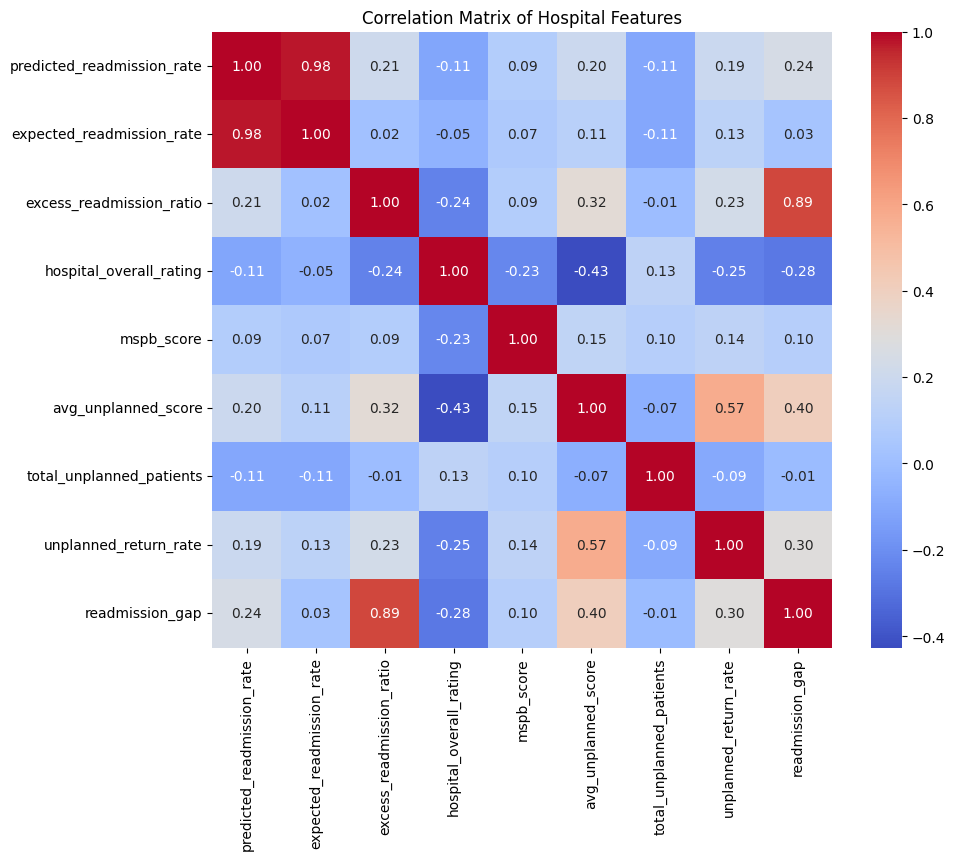

In [0]:
# Plot the correlation matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt= ".2f")
plt.title("Correlation Matrix of Hospital Features")
plt.show()

# 9 Unsupervised Learning: Hospital Segmentaion

## 9.1 Feature Selection

Used operational hospital metrics that capture utilization, cost, and outcomes.

**Note:** Rows with missing values in the clustering features were excluded before fitting the K-Means model. In this dataset, gaps in CMS readmission measures come from how the metrics are defined and reported, not from random data loss, so imputing them could create artificial patterns and distort the resulting clusters.

In [0]:
# Setup clustering features and drop null values
from pyspark.sql import functions as F

cluster_features = [
    "excess_readmission_ratio",
    "mspb_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "hospital_overall_rating",
    "avg_unplanned_score"
]

cluster_df = (
  gold_ml
  .select(*cluster_features)
  .dropna()
)

print("Rows used for clustering:", {cluster_df.count()},"\n")
display(cluster_df.limit(10))

Rows used for clustering: {10916} 



excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score
1.0232,1.04,116,0.4224137931034483,1,27.371428571428574
1.062,1.04,116,0.4224137931034483,1,27.371428571428574
1.0345,1.04,116,0.4224137931034483,1,27.371428571428574
1.0084,1.01,574,0.29965156794425085,1,13.864285714285714
1.0851,1.01,574,0.29965156794425085,1,13.864285714285714
1.0436,1.01,574,0.29965156794425085,1,13.864285714285714
1.0589,1.01,574,0.29965156794425085,1,13.864285714285714
0.9546,1.01,574,0.29965156794425085,1,13.864285714285714
1.049,1.01,574,0.29965156794425085,1,13.864285714285714
1.0865,0.95,792,0.2563131313131313,3,14.666666666666666


## 9.2 Assemble Feature Vector
* Using array_to_vector instead of VectorAssembler function as work around due to the strict Security Whitelisting policies of Databricks Serverless compute.

In [0]:
# Create a vector column from the selected features
from pyspark.ml.functions import array_to_vector

cluster_df_vector = (
  cluster_df
  .withColumn(
    "features_vector",
    array_to_vector(F.array(*[F.col(c) for c in cluster_features]))
  )
)


display(cluster_df_vector.select("features_vector"). limit(10))

features_vector
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0232"",""1.04"",""116.0"",""0.4224137931034483"",""1.0"",""27.371428571428574""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.062"",""1.04"",""116.0"",""0.4224137931034483"",""1.0"",""27.371428571428574""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0345"",""1.04"",""116.0"",""0.4224137931034483"",""1.0"",""27.371428571428574""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0084"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0851"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0436"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0589"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9546"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.049"",""1.01"",""574.0"",""0.29965156794425085"",""1.0"",""13.864285714285714""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0865"",""0.95"",""792.0"",""0.2563131313131313"",""3.0"",""14.666666666666666""]}"


## 9.3 Feature Scaling
* Perform manual scaling instead of ml.feature's StandardScaler due to white listing policy restrictions.

In [0]:
# Create vector column from the selected features
from pyspark.ml.functions import array_to_vector

cluster_features = [
    "excess_readmission_ratio",
    "mspb_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "hospital_overall_rating",
    "avg_unplanned_score"
]

cluster_df = gold_ml.select(*cluster_features).dropna()

stats = cluster_df.select([
  F.mean(c).alias(f"{c}_mean") for c in cluster_features
] + [
F.stddev(c).alias(f"{c}_std") for c in cluster_features
]
).collect()[0].asDict()

display(stats)


{'excess_readmission_ratio_mean': 1.0029456852326866,
 'mspb_score_mean': 0.9986652620007334,
 'total_unplanned_patients_mean': 804.7503664345915,
 'unplanned_return_rate_mean': 0.2926286138889708,
 'hospital_overall_rating_mean': 3.0390252839868084,
 'avg_unplanned_score_mean': 11.318745885364361,
 'excess_readmission_ratio_std': 0.0816206581655322,
 'mspb_score_std': 0.07045578521268431,
 'total_unplanned_patients_std': 657.031739570039,
 'unplanned_return_rate_std': 0.03514963116594327,
 'hospital_overall_rating_std': 1.0788167806762112,
 'avg_unplanned_score_std': 5.388537375528249}

In [0]:
# Scale the features using the mean and standard deviation
scaled_df = cluster_df

for c in cluster_features:
  mean_val = stats[f"{c}_mean"]
  std_val = stats[f"{c}_std"]
  scaled_df = scaled_df.withColumn(f"{c}_scaled", 
                                   (F.col(c)-F.lit(mean_val))/F.lit(std_val))
  
  scaled_cols = [f"{c}_scaled" for c in cluster_features]

  df_scaled = (
    scaled_df.withColumn(
      "features_vector",
      array_to_vector(F.array(*[F.col(c) for c in scaled_cols])
    )
  ))

display(df_scaled.select("features_vector").limit(10))


features_vector
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.24815181870056016"",""0.5866762803720069"",""-1.0482756386857492"",""3.692362477482474"",""-1.8900570704033084"",""2.9790426543140636""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7235216683446408"",""0.5866762803720069"",""-1.0482756386857492"",""3.692362477482474"",""-1.8900570704033084"",""2.9790426543140636""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.3865971615092729"",""0.5866762803720069"",""-1.0482756386857492"",""3.692362477482474"",""-1.8900570704033084"",""2.9790426543140636""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.06682517502188817"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.006538254086348"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.4980885437711593"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.6855410875741073"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""-0.5923216783505746"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.564248265113375"",""0.1608773213590704"",""-0.35120124727245944"",""0.1998016429283224"",""-1.8900570704033084"",""0.47239902992633664""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0236907744343309"",""-0.6907205966668027"",""-0.019406012931635973"",""-1.0331682402125981"",""-0.03617415365225132"",""0.621304177364846""]}"


##  9.4 Optimal Cluster Selection
* Prepare clustering data in Pandas due to white listing policy restrictions.

In [0]:
# Convert the Spark DataFrame to a Pandas DataFrame with selected features
cluster_features = [
    "excess_readmission_ratio",
    "mspb_score",
    "total_unplanned_patients",
    "unplanned_return_rate",
    "hospital_overall_rating",
    "avg_unplanned_score"
]

# Convert the Spark DataFrame to a Pandas DataFrame with selected features
# NAs are dropped
cluster_pd = gold_ml.select(*cluster_features).dropna().toPandas()

print("Rows used for clustering:", len(cluster_pd))
cluster_pd.head()

Rows used for clustering: 10916


,excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score
0,1.0232,1.04,116,0.422414,1,27.371429
1,1.0620,1.04,116,0.422414,1,27.371429
2,1.0345,1.04,116,0.422414,1,27.371429
3,1.0084,1.01,574,0.299652,1,13.864286
4,1.0851,1.01,574,0.299652,1,13.864286


### 9.4.1 Standardize Features with Sklearn

In [0]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_pd[cluster_features])


In [0]:
print(display(X_scaled.shape))
print(display(X_scaled[:5]))

(10916, 6)

None


array([[ 0.24816319,  0.58670315, -1.04832366,  3.69253162, -1.89014365,
         2.97917912],
       [ 0.72355481,  0.58670315, -1.04832366,  3.69253162, -1.89014365,
         2.97917912],
       [ 0.38661487,  0.58670315, -1.04832366,  3.69253162, -1.89014365,
         2.97917912],
       [ 0.06682824,  0.16088469, -0.35121733,  0.1998108 , -1.89014365,
         0.47242067],
       [ 1.00658436,  0.16088469, -0.35121733,  0.1998108 , -1.89014365,
         0.47242067]])

None


### 9.4.2 Elbow Method

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff0a0616a8e0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

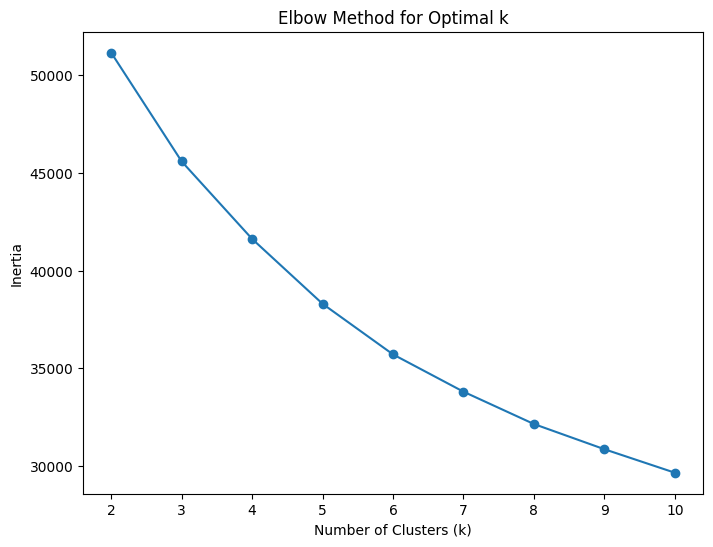

In [0]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = list(range(2, 11))
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters= k, random_state= 42, n_init= 10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)


plt.figure(figsize= (8,6))
plt.plot(k_values, inertia_values, marker= 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

**9.4.2 Output:** The elbow method was used to determine the optimal number of clusters by examining the within-cluster sum of squares (Inertia) across different values of k. The curve shows a sharp decrease in inertia up to approximately k = 5, after which the rate of improvement diminishes significantly. Therefore, k = 5 was selected as the optimal number of clusters for hospital segmentation.

### 9.4.3 Silhoutte Score

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff098bbf28e0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

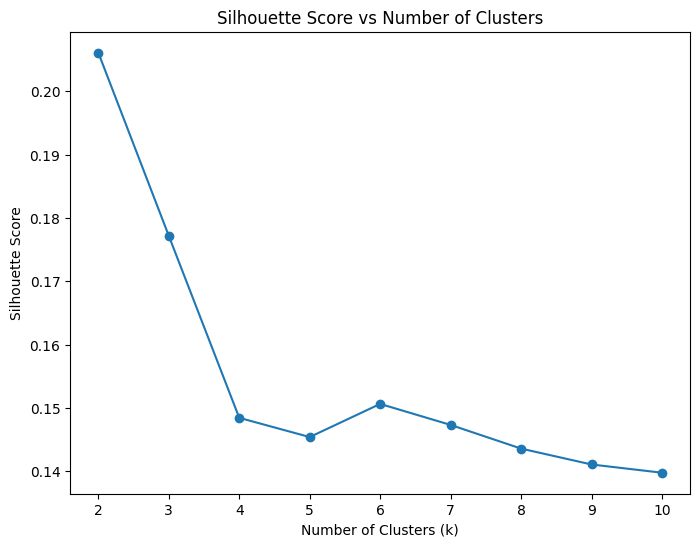

Silhouette Score` [0.20608859661601617, 0.17718021419632066, 0.14844407906409127, 0.1454095620710007, 0.1506400740802188, 0.14732390859556876, 0.14358810769253297, 0.1410793846660219, 0.13977695264291592]


In [0]:
from sklearn.metrics import silhouette_score

silhouette_score_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_score_list.append(silhouette_score(X_scaled, kmeans.labels_))


plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_score_list, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

print("Silhouette Score`", list(silhouette_score_list))

**9.4.3 Output:** The optimal number of clusters was determined using both the elbow method and silhouette analysis. The elbow plot flattened out around 5–6 clusters, meaning that adding more clusters after that only slightly reduced the within‑cluster variation.

The silhouette score peaked at 2 clusters, which is typical but would split hospitals into segments that are too broad to be useful. After 3 clusters, the silhouette scores were fairly similar, indicating that cohesion did not change much as we increased k.

Balancing these metrics with how interpretable the hospital segments are, we chose 5 clusters as the final solution.

## 9.5 K-Means Model

In [0]:
cluster_pd.columns

Index(['excess_readmission_ratio', 'mspb_score', 'total_unplanned_patients',
       'unplanned_return_rate', 'hospital_overall_rating',
       'avg_unplanned_score'],
      dtype='object')

In [0]:
best_k = 5

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_pd["cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_pd[["cluster"] + cluster_features].head()

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff0983646f20>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

,cluster,excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score
0,2,1.0232,1.04,116,0.422414,1,27.371429
1,2,1.0620,1.04,116,0.422414,1,27.371429
2,2,1.0345,1.04,116,0.422414,1,27.371429
3,3,1.0084,1.01,574,0.299652,1,13.864286
4,2,1.0851,1.01,574,0.299652,1,13.864286


In [0]:
# Reminder cluster_features checked
cluster_features

['excess_readmission_ratio',
 'mspb_score',
 'total_unplanned_patients',
 'unplanned_return_rate',
 'hospital_overall_rating',
 'avg_unplanned_score']

### 9.5.1 Cluster Counts and Cluster Distribution Plot

In [0]:
# Value counts of clusters

cluster_counts = (
  cluster_pd["cluster"]
  .value_counts()
  .sort_index()
  .reset_index()
)

cluster_counts.columns = ["cluster", "count"]

cluster_counts

,cluster,count
0,0,1419
1,1,2765
2,2,1610
3,3,2635
4,4,2487


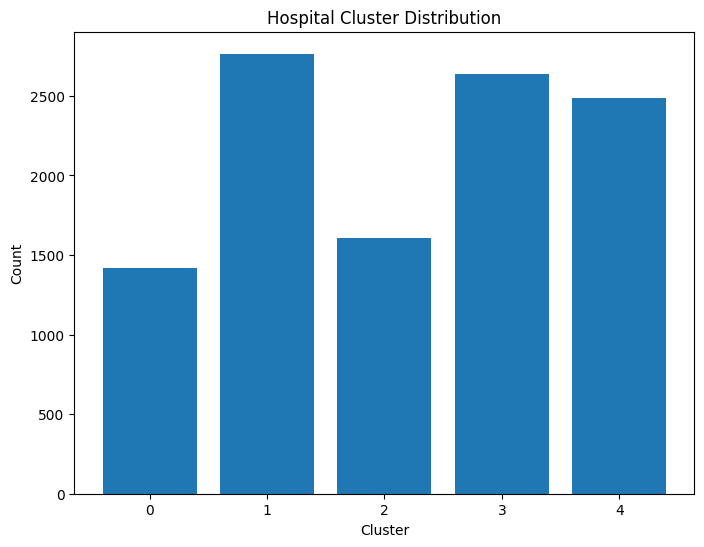

In [0]:
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts["cluster"], cluster_counts["count"])
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Hospital Cluster Distribution")
plt.show()

## 9.6 Cluster Profiles

### 9.6.1 Cluster Profiles Tables

In [0]:
cluster_profiles = (
    cluster_pd
    .groupby("cluster")[cluster_features]
    .mean()
    .reset_index()
    .sort_values("cluster")
)

cluster_profiles

,cluster,excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score
0,0,1.005042,1.003911,2030.537703,0.281500,3.604651,10.512269
1,1,1.018225,0.953816,553.626040,0.308086,3.239783,11.861347
2,2,1.068069,1.026137,528.277640,0.334949,1.875776,19.248639
3,3,1.000253,1.055268,744.154839,0.285743,2.426186,10.993052
4,4,0.945457,0.967780,627.732610,0.261691,3.895456,6.387171


### 9.6.2 Cluster Individual Profile Plots

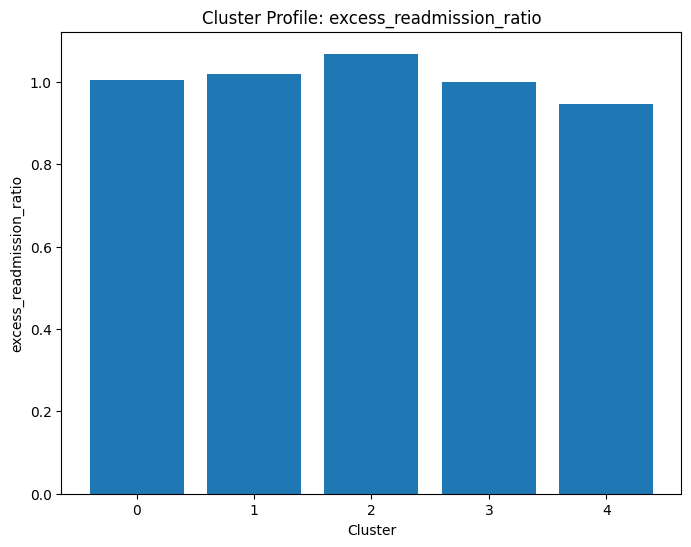

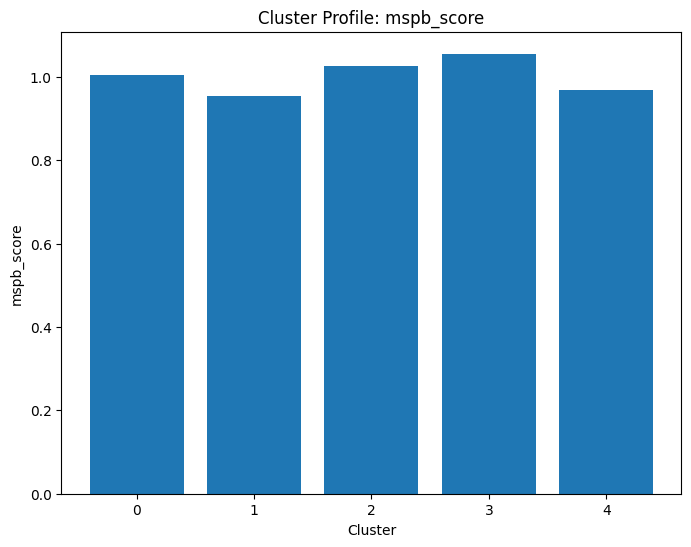

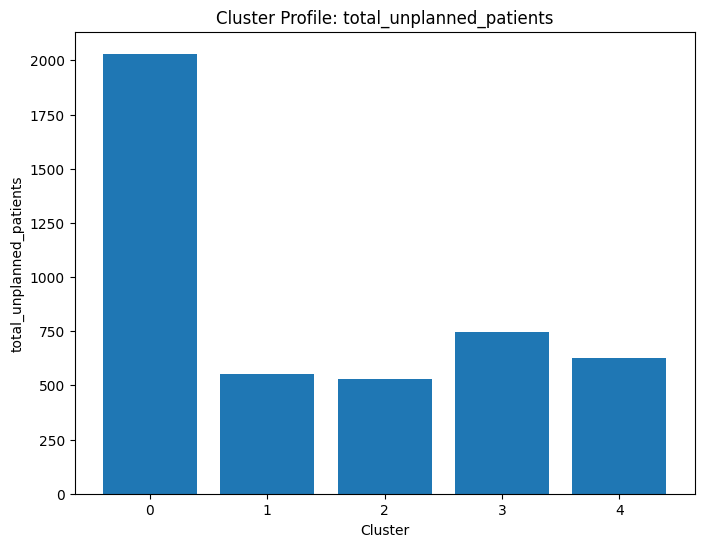

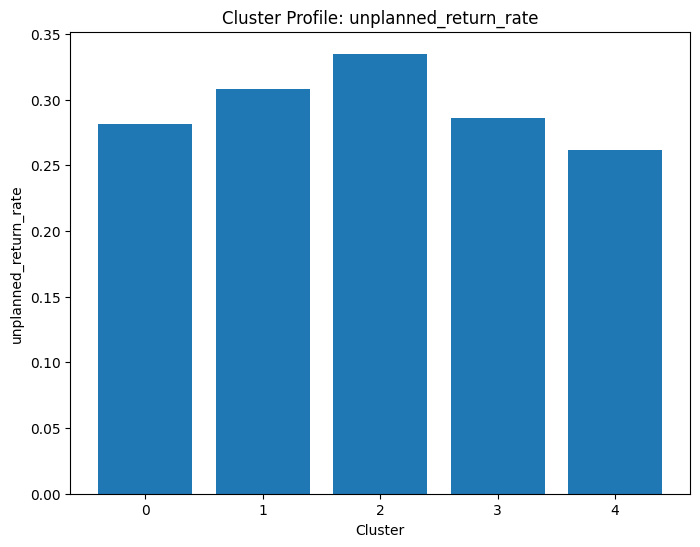

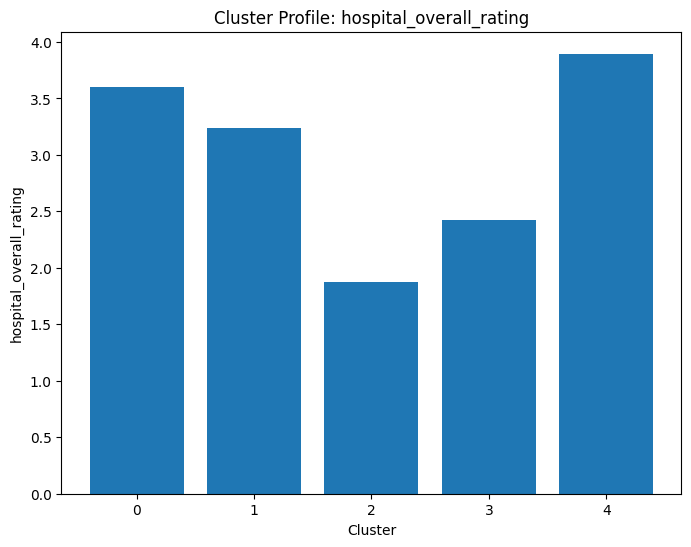

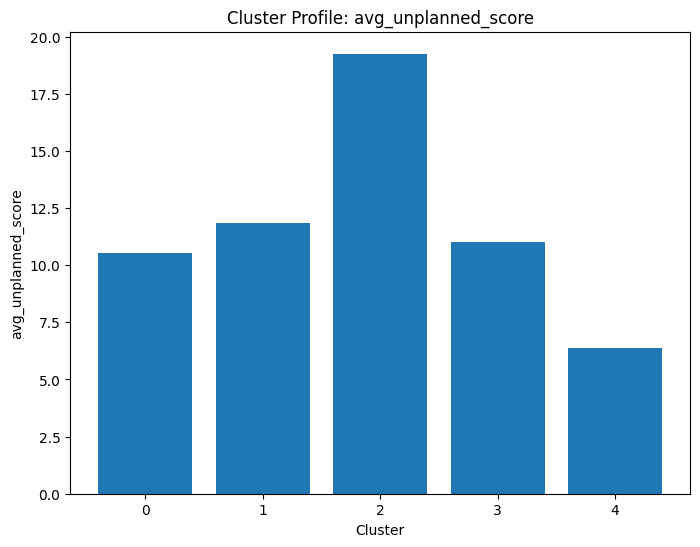

In [0]:
# Plot cluster profiles

for feature in cluster_features:
    plt.figure(figsize=(8, 6))
    plt.bar(cluster_profiles["cluster"], cluster_profiles[feature])
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.title(f"Cluster Profile: {feature}")
    plt.show()


**9.6.2 Output:** Cluster Interpretation

K-Means clustering produced five hospital segments. Since clustering algorithms assign numeric cluster IDs without inherent meaning, descriptive labels were derived by examining the average feature values within each cluster, including patient volume, readmission metrics, spending indicators, and hospital quality ratings.

Based on the cluster profile analysis, the following hospital segments were identified:

**Cluster 0 — Large Metropolitan Hospitals**
* Very high patient volume
* Good hospital ratings (~3.6)
* Moderate readmission ratios

These hospitals likely represent large urban facilities handling high patient throughput.

---

**Cluster 1 — Typical Community Hospitals**
* Medium patient volume
* Moderate hospital ratings (~3.2)
* Slightly elevated unplanned return rates

This segment represents average regional hospitals with typical operational performance.

---

**Cluster 2 — Underperforming Hospitals**
* Lowest hospital ratings
* Highest readmission ratios
* Highest unplanned return rates

Hospitals in this cluster show the weakest performance across key readmission indicators.

---

**Cluster 3 — Higher-Cost Hospitals**
* Highest Medicare Spending per Beneficiary (MSPB)
* Moderate readmission ratios
* Lower hospital ratings

These hospitals appear to have higher spending levels relative to outcomes.

---

**Cluster 4 — High-Quality Hospitals**
* Highest hospital ratings
* Lowest readmission ratios
* Lowest unplanned return rates

This cluster represents the strongest-performing hospitals across the analyzed quality metrics.

### 9.6.2.1

## 9.7 PCA Visualization

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the clustering feature space while preserving the majority of variance. Two principal components were selected for visualization purposes, allowing cluster separation to be visualized in two-dimensional space while retaining most of the underlying data variability.

### 9.7.1 Finding Best PCA Components

In [0]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance per component:")
print(explained_variance)

print("\nCumulative variance:")
print(cumulative_variance)

Explained variance per component:
[0.36162301 0.18346116 0.15184955 0.13176476 0.11093062 0.06037091]

Cumulative variance:
[0.36162301 0.54508417 0.69693371 0.82869847 0.93962909 1.        ]


**9.7.1 Output:** Principal Component Analysis (PCA) was used to examine how much variance each component captures from the clustering feature set.

The first two principal components explain approximately **54.5% of the total variance**, while the first four components explain approximately **82.9% of the variance**.

Although additional components capture more information, **two components were selected for visualization purposes**, allowing the cluster structure to be visualized in two-dimensional space.


#### 9.7.1.1 Scree Plot
This plot helps with ncomponent cutoff or highest variance.

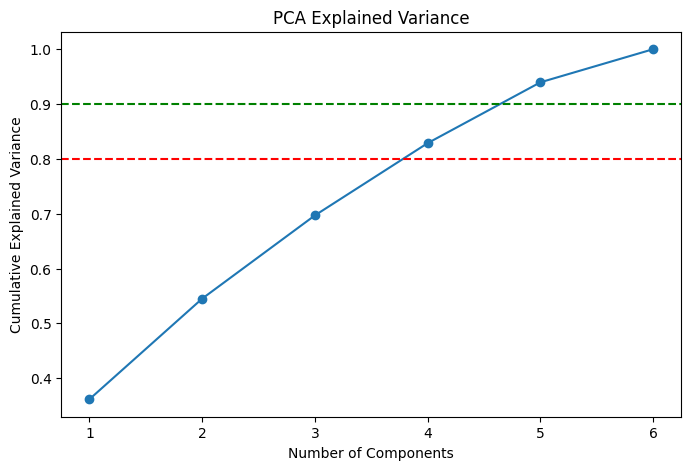

In [0]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.axhline(y=0.80, color='r', linestyle='--')
plt.axhline(y=0.90, color='g', linestyle='--')

plt.show()

#### 9.7.1.2 PCA Component Analysis

In [0]:
# View the pca components of the features in a dataframe
import pandas as pd

loadings = pd.DataFrame(
    pca.components_,
    columns=cluster_features
)

loadings

,excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score
0,0.371044,0.225330,-0.156050,0.498534,-0.460422,0.571556
1,0.109041,0.634512,0.731986,-0.212784,-0.065465,0.011778
2,0.535744,-0.581518,0.495253,0.158525,0.299988,0.120066
3,-0.651089,0.016125,0.268937,0.549556,0.344421,0.287853
4,0.367712,0.455497,-0.327002,0.198389,0.706054,-0.111842
5,-0.065465,-0.026831,-0.123740,-0.582827,0.276757,0.750601


### 9.7.2 PCA Plot  

In [0]:
# Check the first 2 rows of the dataframe
cluster_pd.head(2)

,excess_readmission_ratio,mspb_score,total_unplanned_patients,unplanned_return_rate,hospital_overall_rating,avg_unplanned_score,cluster
0,1.0232,1.04,116,0.422414,1,27.371429,2
1,1.0620,1.04,116,0.422414,1,27.371429,2


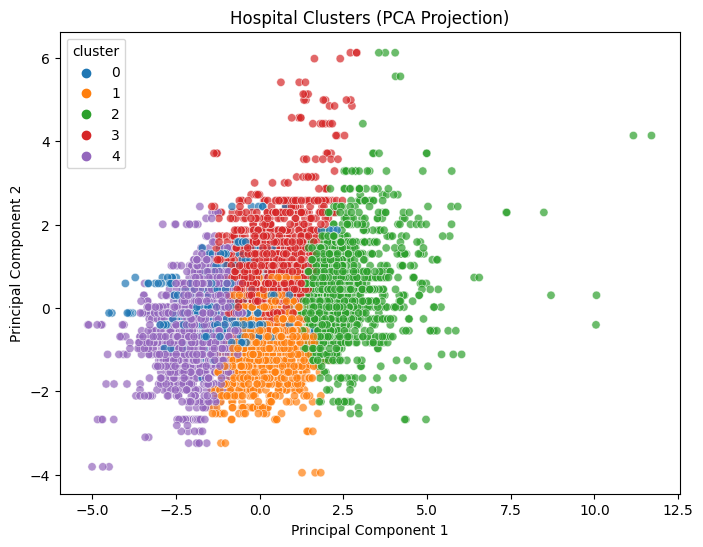

In [0]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2, random_state= 42)
X_scaled_pca = pca.fit_transform(X_scaled)

cluster_pd["pc1"] = X_scaled_pca[:, 0]
cluster_pd["pc2"] = X_scaled[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cluster_pd,
    x="pc1",
    y="pc2",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Hospital Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


**9.7.2 Output:** PCA Visualization of Hospital Clusters
* To better visualize the clustering results, Principal Component Analysis (PCA) was applied to reduce the feature space into two dimensions. This allows the hospital clusters identified by the K-Means model to be plotted and visually inspected.
The first two principal components explain approximately **54.5% of the total variance** in the dataset. While this does not capture all of the variance, it is sufficient to provide a meaningful two-dimensional representation of the hospital feature space.
* From the PCA projection, the clusters show identifiable patterns in how hospitals group together based on operational characteristics such as patient volume, readmission behavior, spending metrics, and overall hospital ratings. Some overlap between clusters is expected given the complexity of healthcare systems and the similarity of certain hospital profiles.

Overall, the visualization supports the earlier cluster profiling results and helps illustrate how different hospital segments relate to one another in the feature space.


# 10 Key Findings

The exploratory analysis of CMS hospital data reveals several meaningful patterns related to hospital performance, readmission behavior, patient volume, and cost structures.

### 1. Hospital Ratings and Readmission Performance
Hospitals with higher overall ratings generally show lower excess readmission ratios. While the relationship is not perfectly linear, the distribution indicates that higher-rated hospitals tend to manage patient outcomes more effectively, resulting in fewer readmissions relative to expected levels.

### 2. Rural vs Metropolitan Differences
Hospitals located in rural areas tend to have lower patient volumes compared to metropolitan hospitals. Rural hospitals also show greater variability in readmission performance, which may reflect differences in available resources, patient demographics, and healthcare accessibility.

### 3. Patient Volume Patterns
Large metropolitan hospitals handle significantly higher patient volumes, particularly in unplanned patient visits. However, higher patient volume does not necessarily translate to better performance, as some high-volume hospitals still exhibit elevated readmission ratios.

### 4. Cost and Utilization
The Medicare Spending per Beneficiary (MSPB) metric varies across hospitals and clusters. Some hospitals show relatively high spending without corresponding improvements in readmission outcomes, suggesting possible inefficiencies in healthcare delivery.

### 5. Hospital Segmentation
Using K-Means clustering, hospitals can be grouped into several distinct operational profiles. These clusters reflect differences in patient volume, hospital quality ratings, spending patterns, and readmission behavior.

The clustering analysis identified five general hospital segments:

• **Large metropolitan hospitals** – high patient volume with moderate readmission levels  
• **Typical community hospitals** – medium patient volume with average performance  
• **Underperforming hospitals** – lower ratings with higher readmission ratios  
• **Higher-cost hospitals** – elevated spending levels with moderate outcomes  
• **High-quality hospitals** – strong ratings with relatively low readmission rates  

### 6. Cluster Visualization
Principal Component Analysis (PCA) was used to project the hospital feature space into two dimensions. The PCA visualization confirms that the clusters represent meaningful groupings of hospital characteristics, although some overlap exists due to similarities among certain hospital profiles.

### 7. Implications for Modeling
These exploratory findings highlight several variables that may be useful predictors in downstream modeling tasks, including:

- hospital overall rating
- MSPB spending score
- patient volume indicators
- unplanned return rate
- rural vs metropolitan classification

These features will be used in the next stage of the project to build predictive models for hospital readmission performance.
